In [1]:
import torch
import torch.nn as nn
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.11.1
torch version: 2.13.0
tiktoken version: 0.13.0


In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

### GPT Building blocks
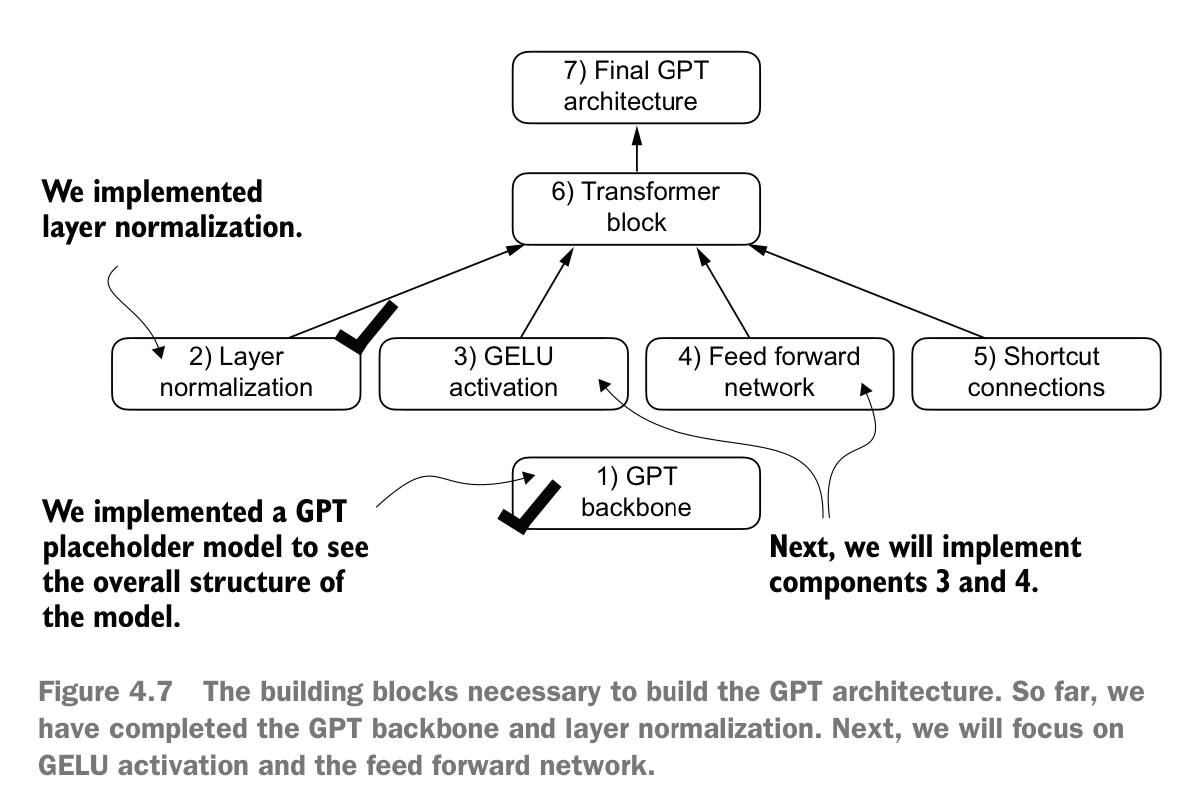

In [3]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        # Does nothing just forwards the input
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):     # Mimic input of LayerNorm
        super().__init__()

    def forward(self, x):
        # Does nothing just forwards the input
        return x

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Transformer blocks
        self.trf_blocs = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )

        # Final layers
        self.final_layer_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, x):
        # Extract shapes
        batch_size, seq_length = x.size()

        # Token and position embeddings
        tok_emb = self.tok_emb(x)
        pos_emb = self.pos_emb(
            torch.arange(seq_length, device=x.device)
        )

        x = tok_emb + pos_emb
        x = self.drop_emb(x)

        # Pass through transformer blocks
        x = self.trf_blocs(x)

        # Final layers
        self.final_layer_norm(x)
        logits = self.out_head(x)
        return logits

### General Overview
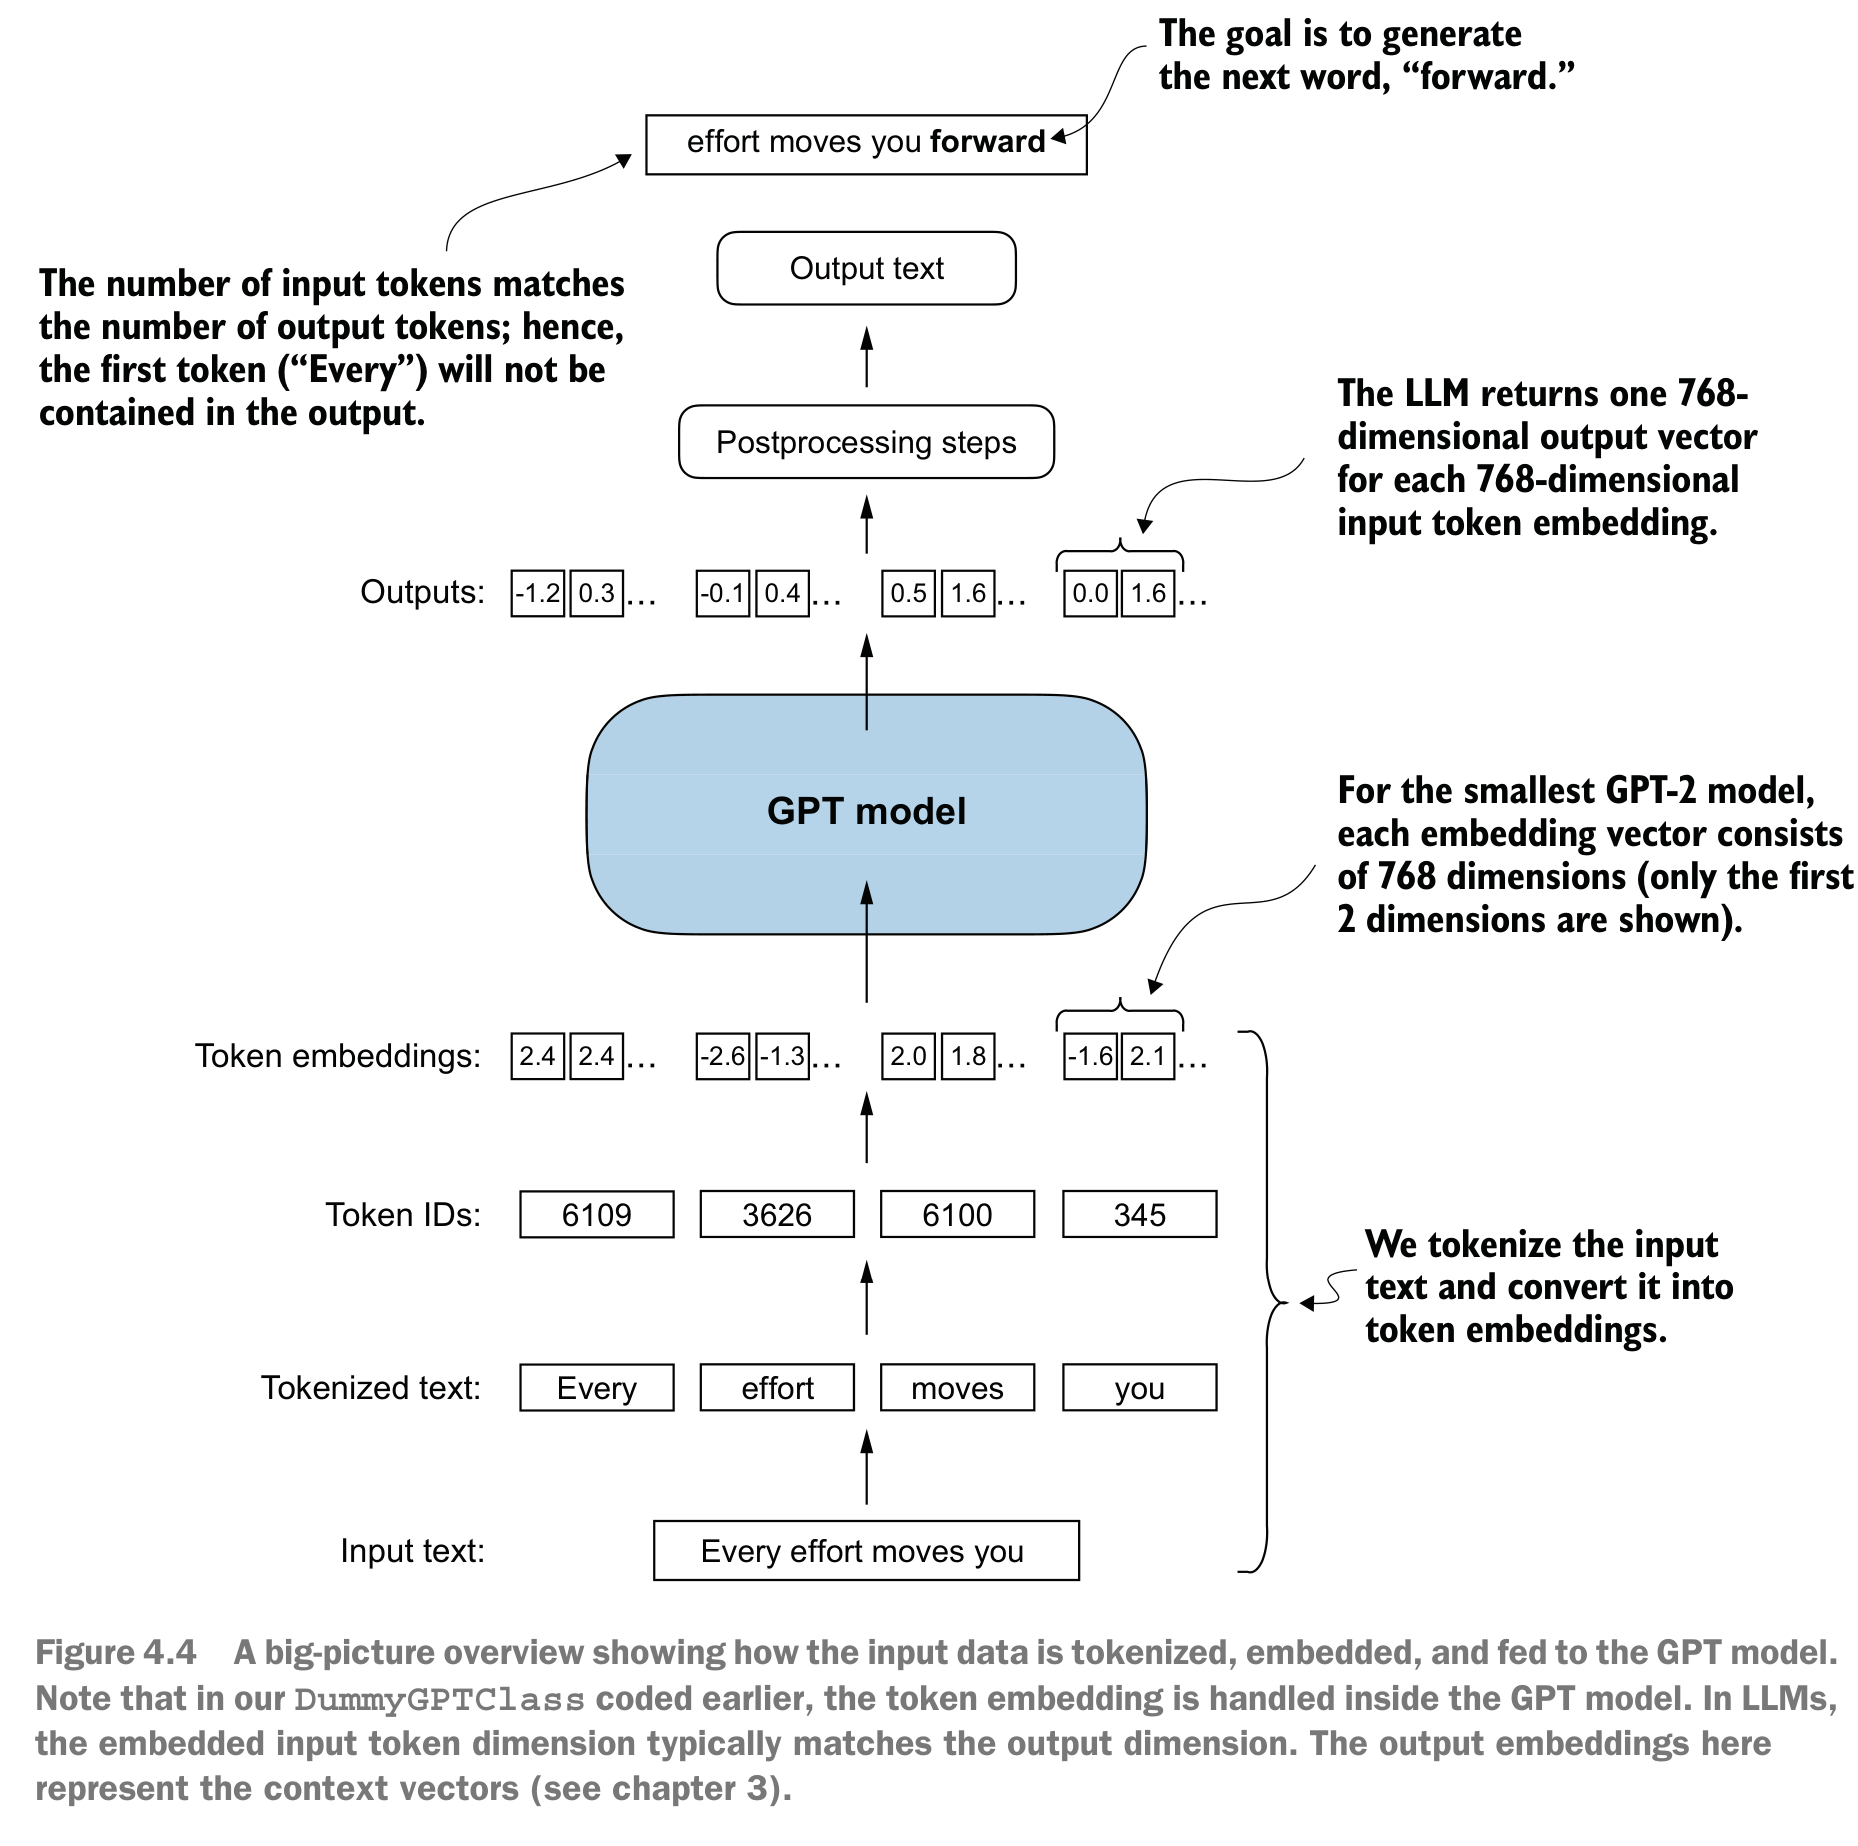

In [4]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

print("Batch shape:", batch.shape)
print(batch)

Batch shape: torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:

tok_emb = nn.Embedding(GPT_CONFIG_124M["vocab_size"], GPT_CONFIG_124M["emb_dim"])
print(f"Token embedding shape: {tok_emb.weight.shape}")

batch_size, seq_length = batch.size()
print(f"Batch size: {batch_size}, Sequence length: {seq_length}")

tok_emb_out = tok_emb(batch)
print(f"Token embedding output shape: {tok_emb_out.shape}")

Token embedding shape: torch.Size([50257, 768])
Batch size: 2, Sequence length: 4
Token embedding output shape: torch.Size([2, 4, 768])


In [6]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

print(GPT_CONFIG_124M)

logits = model(batch)
print("Logits shape:", logits.shape)
print(logits)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
Logits shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### Normalizing Activation
Main idea:
- Adjust activation (outputs) so they have unit variance (mean = 0, var = 1)
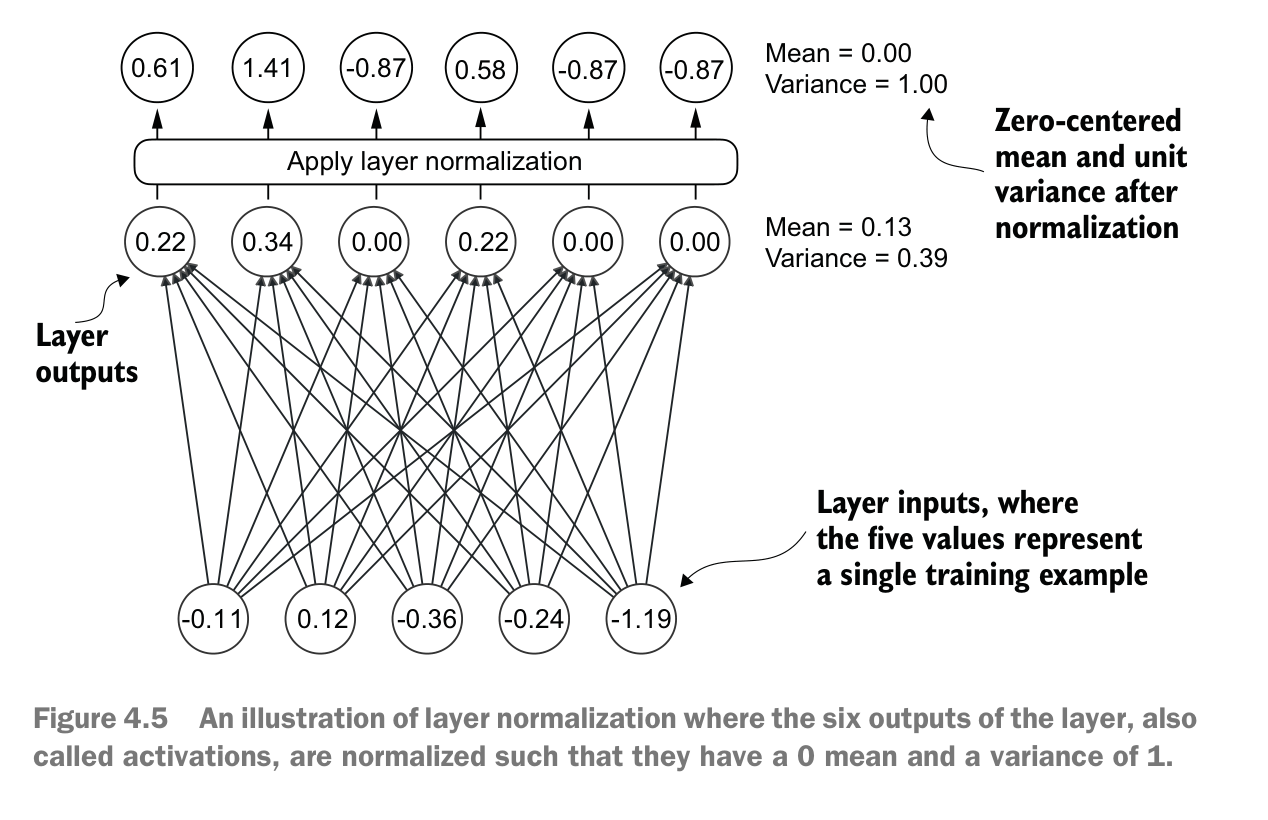

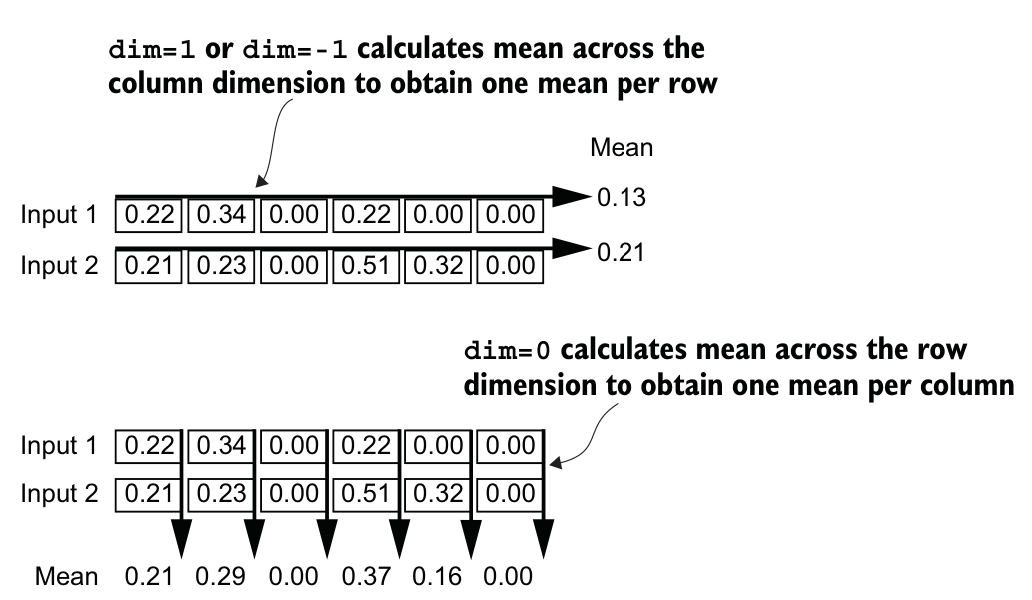

In [7]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(
    nn.Linear(5, 6),
    nn.ReLU(),
)
out = layer(batch_example)
print(f"out shape: {out.shape}")
print(f"out:\n{out}")

print("-----------------------------")
print("Mean of out along last dimension (dim=-1):")
print(out.mean(dim=-1, keepdim=True))
print()


print("Variance of out along last dimension (dim=-1):")
print(out.var(dim=-1, keepdim=True))
print()

out shape: torch.Size([2, 6])
out:
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
-----------------------------
Mean of out along last dimension (dim=-1):
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

Variance of out along last dimension (dim=-1):
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)



In [8]:
# Layer normalization with sqrt of variance (i.e. standard deviation)
mean = out.mean(dim=-1, keepdim=True)
variance = out.var(dim=-1, keepdim=True)
std_dev = torch.sqrt(variance)  # Adding epsilon for numerical stability

norm_out = (out - mean) / std_dev
print("Normalized output (out - mean) / std_dev:")
print(norm_out)

print("Mean of normalized output along last dimension (dim=-1):")
print(norm_out.mean(dim=-1, keepdim=True))
print()

print("Variance of normalized output along last dimension (dim=-1):")
print(norm_out.var(dim=-1, keepdim=True))



Normalized output (out - mean) / std_dev:
tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean of normalized output along last dimension (dim=-1):
tensor([[9.9341e-09],
        [3.9736e-08]], grad_fn=<MeanBackward1>)

Variance of normalized output along last dimension (dim=-1):
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [9]:
### Layer Norm Class 
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim
        self.eps = 1e-5

        # Trainable Params that LLM adjusts during training
        # Allows model to learn appropriat scaling and shifting
        # that best suits the data processing
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift
        

In [10]:
print(f"batch_example {batch_example.shape}:\n{batch_example}")

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

print("--------")
print(f"out_ln {out_ln.shape}:\n{out_ln}")

print(f"Mean:\n{out_ln.mean(dim=-1, keepdim=True)}")
print(f"Variance:\n{out_ln.var(dim=-1, keepdim=True)}")

batch_example torch.Size([2, 5]):
tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
--------
out_ln torch.Size([2, 5]):
tensor([[ 0.4945,  0.9564, -0.0200,  0.2375, -1.6685],
        [ 0.8127, -1.2313, -0.8554,  1.0110,  0.2630]], grad_fn=<AddBackward0>)
Mean:
tensor([[-1.4901e-08],
        [ 2.3842e-08]], grad_fn=<MeanBackward1>)
Variance:
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### GELU Activations

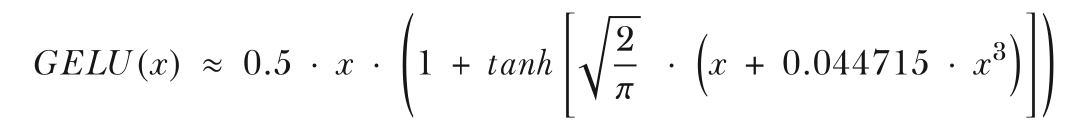
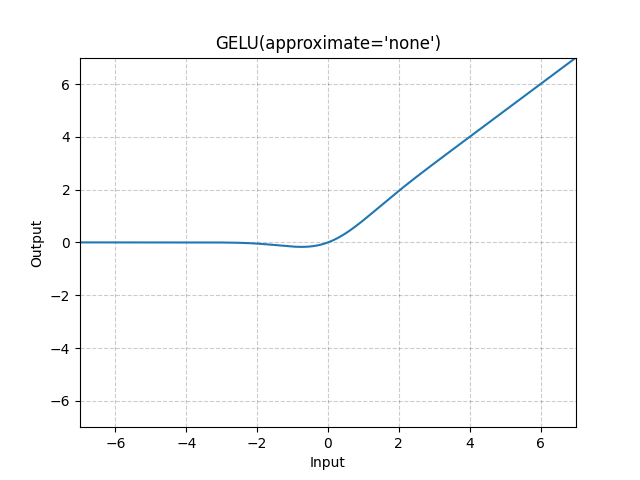

In [11]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
                (x + 0.044715 * torch.pow(x, 3))
                )
        )

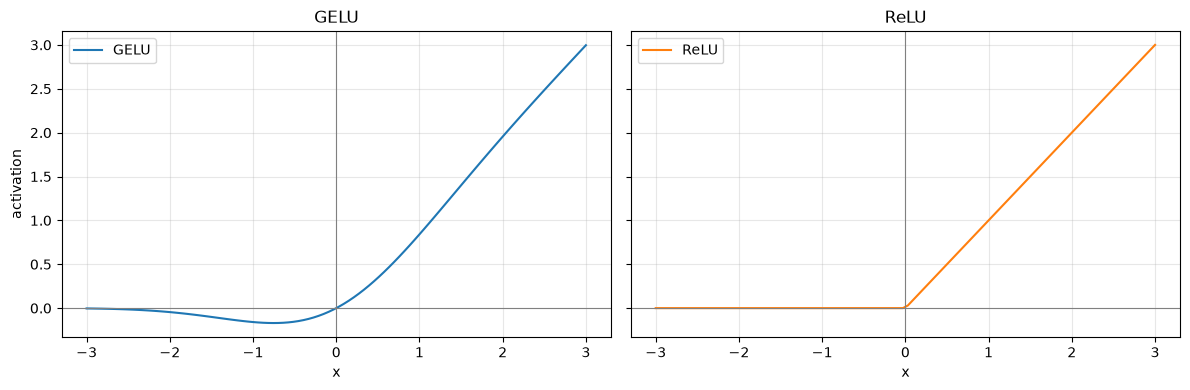

In [12]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].plot(x, y_gelu, color="tab:blue", label="GELU")
axes[0].set_title("GELU")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].axvline(0, color="gray", lw=0.8)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x, y_relu, color="tab:orange", label="ReLU")
axes[1].set_title("ReLU")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].grid(alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("activation")

plt.tight_layout()
plt.show()

Smoothness of GELU can lead to better optimization alllowing for better adjustments to models param
- GELU smooth function with non-zero gradient for almost all negative values except for about approximately x=-0.75
- RELU has a sharp corner at 0, causing harder optimization. RELU also outputs 0 for negative inputs while in GELU small non-zero negative inputs can still have a contribution

### Feedforward

In [13]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


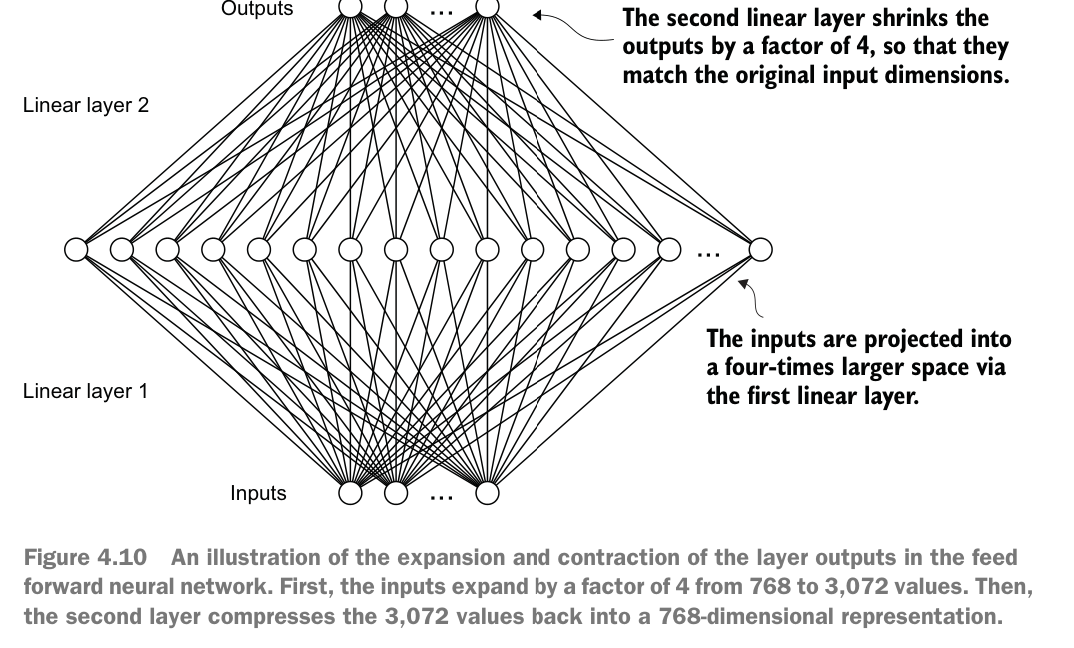

- By allowing uniformity in input/output simplifies architecture. Allows for multiple stacking of these layers easily
- Expanding the embedding space internally to x4 times followed by GELU allows for a richer representation of the space.

### Shortcut Connections/Skip Connections
In order to deal with vanishing gradients, i.e when gradients become progressively smaller as they backprop through layers (making it more difficult to train/learn), can use skip connections.
- provides alternative/shorter path for gradient to flow through network. This is done by adding output of on layer to output of a later layer.
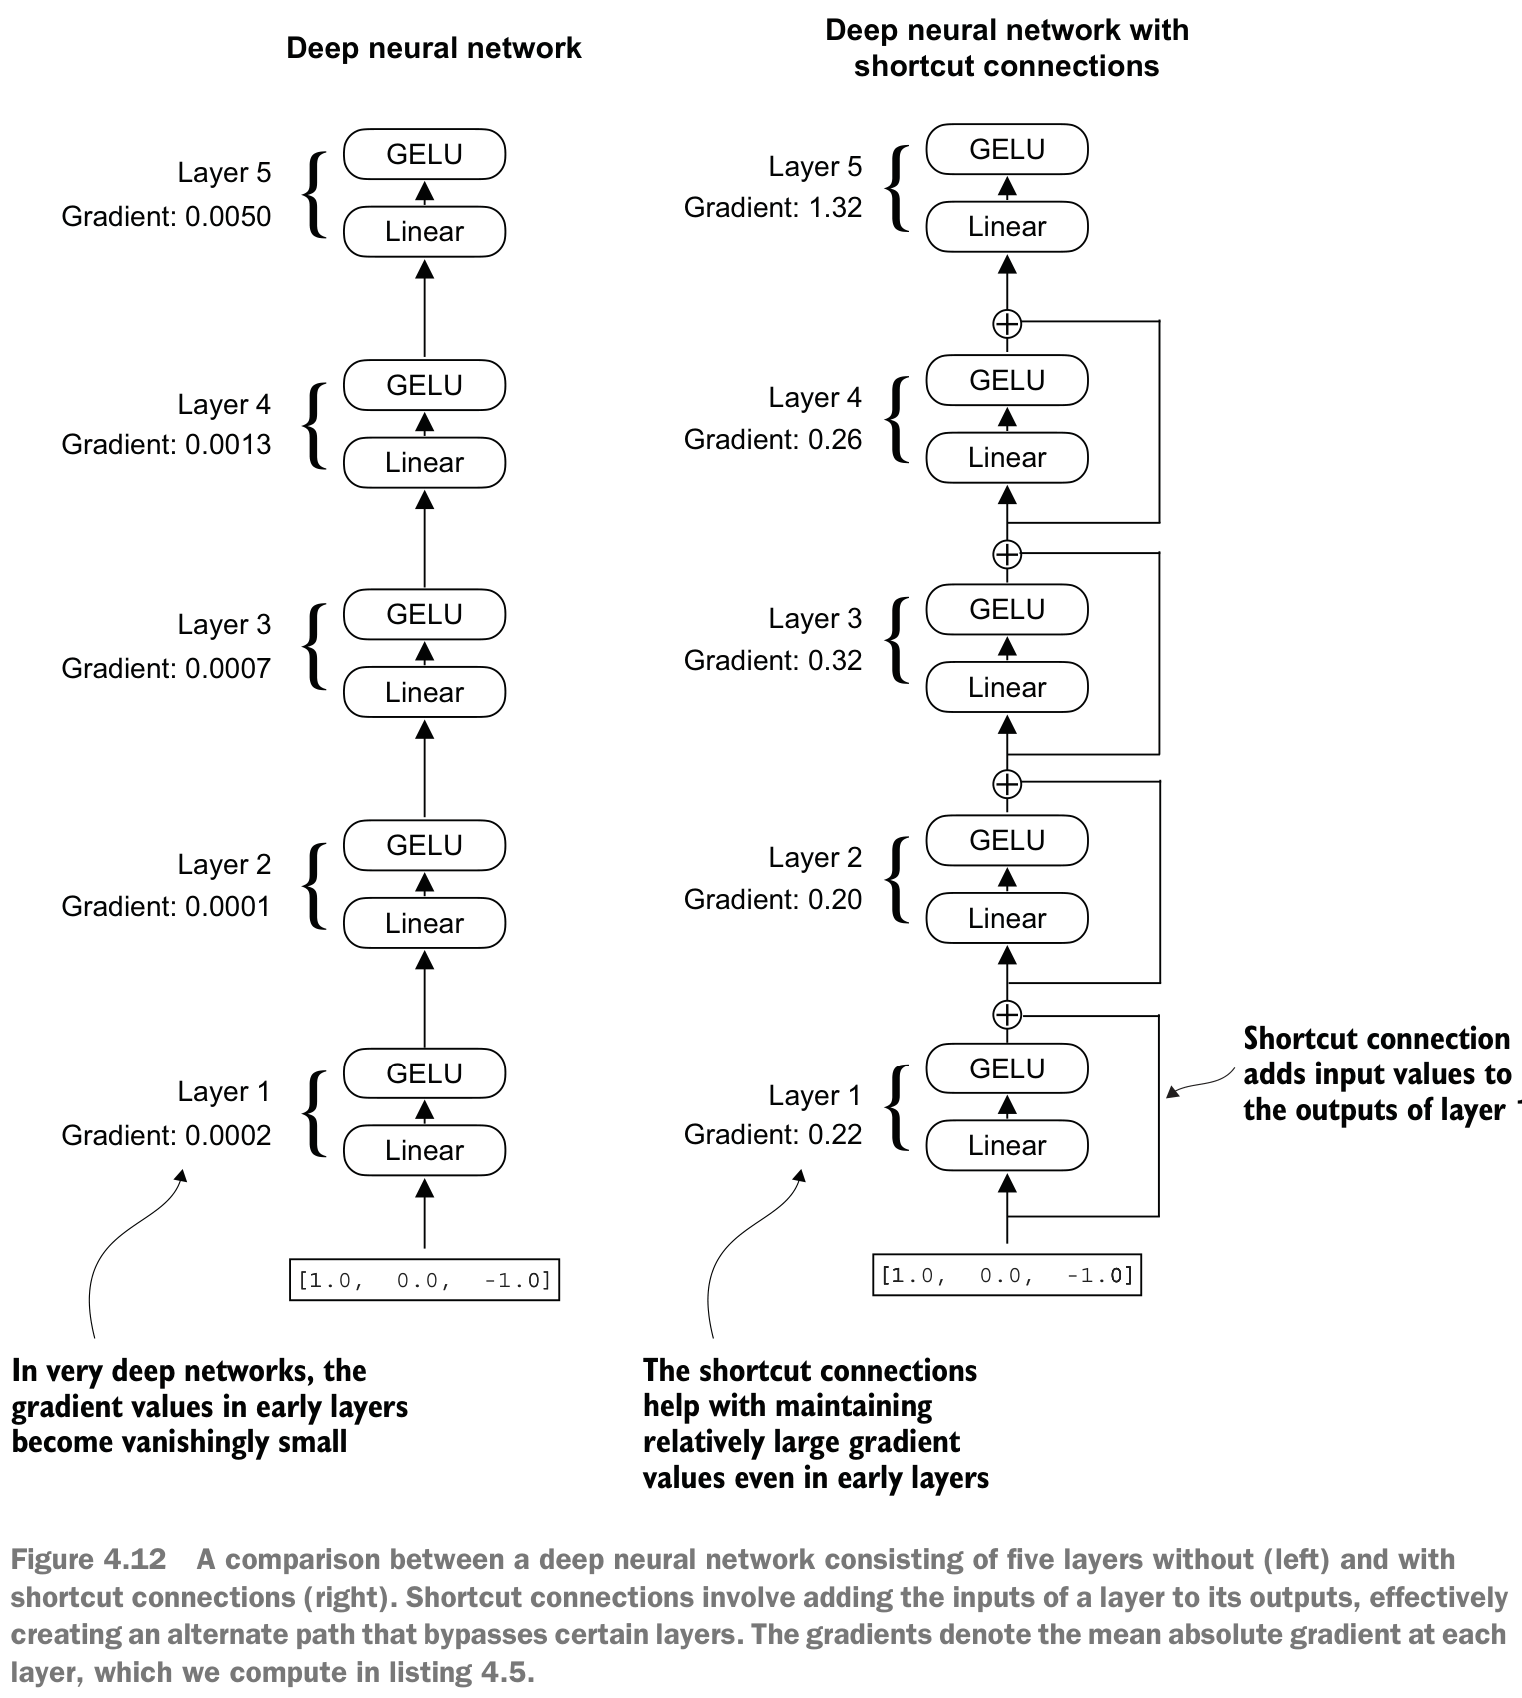

In [15]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute output of current layer
            layer_output = layer(x)

            # Check for shortcuts
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([0.])

    # Calculate loss based on how close targets 
    # and outputs are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

def boxplot_weight_abs_grad_by_layers(model):
    # Plot weight gradient values by layer (boxplot)
    grad_tensors = [
        (name, param.grad.detach().flatten().cpu().numpy())
        for name, param in model.named_parameters()
        if "weight" in name and param.grad is not None
    ]

    if not grad_tensors:
        print("No weight gradients found. Run a backward pass first.")
        return

    layer_names = [name for name, _ in grad_tensors]
    layer_grads = [g for _, g in grad_tensors]

    plt.figure(figsize=(max(8, 1.6 * len(layer_names)), 4))
    plt.boxplot(layer_grads, tick_labels=layer_names, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Gradient value")
    plt.title("Weight gradients by layer")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_weight_grad_by_layers(model):
    # Collect weight tensors by layer
    weight_tensors = [
        (name, param.detach().flatten().cpu())
        for name, param in model.named_parameters()
        if "weight" in name
    ]

    if not weight_tensors:
        print("No weights found.")
        return

    n_layers = len(weight_tensors)
    fig, axes = plt.subplots(1, n_layers, figsize=(max(10, 3.2 * n_layers), 3.5), squeeze=False)
    axes = axes[0]

    for ax, (name, w) in zip(axes, weight_tensors):
        ax.bar(range(w.numel()), w.numpy(), color="tab:blue")
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Weight index")
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Weight value")
    plt.tight_layout()
    plt.show()

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011158833047375
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


/home/ein/miniconda3/envs/deepl/lib/python3.11/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


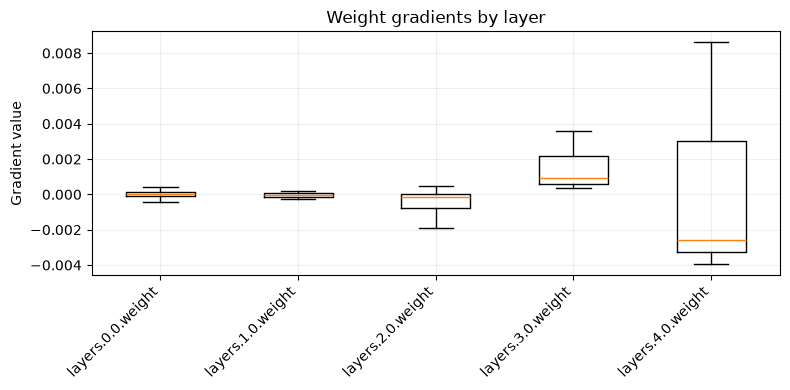

In [16]:
# -- Gradient analysis without shortcut
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)
boxplot_weight_abs_grad_by_layers(model=model_without_shortcut)
# plot_weight_grad_by_layers(model=model)   # TOO SLOW

layers.0.0.weight has gradient mean of 0.22169794142246246
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


/home/ein/miniconda3/envs/deepl/lib/python3.11/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


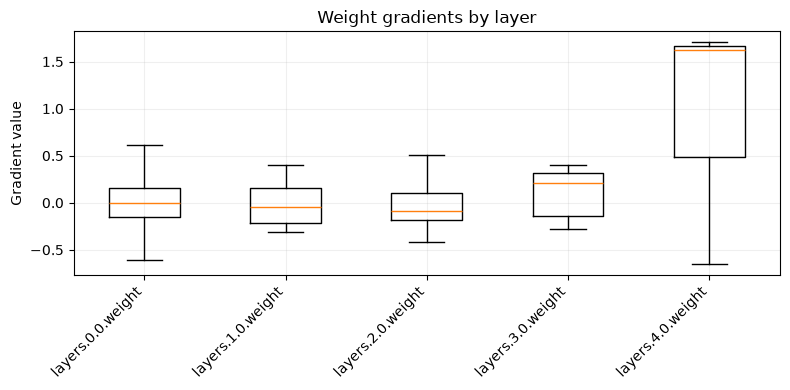

In [17]:
# -- Gradient analysis with shortcut
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)
boxplot_weight_abs_grad_by_layers(model=model_with_shortcut)

### Transformer Block

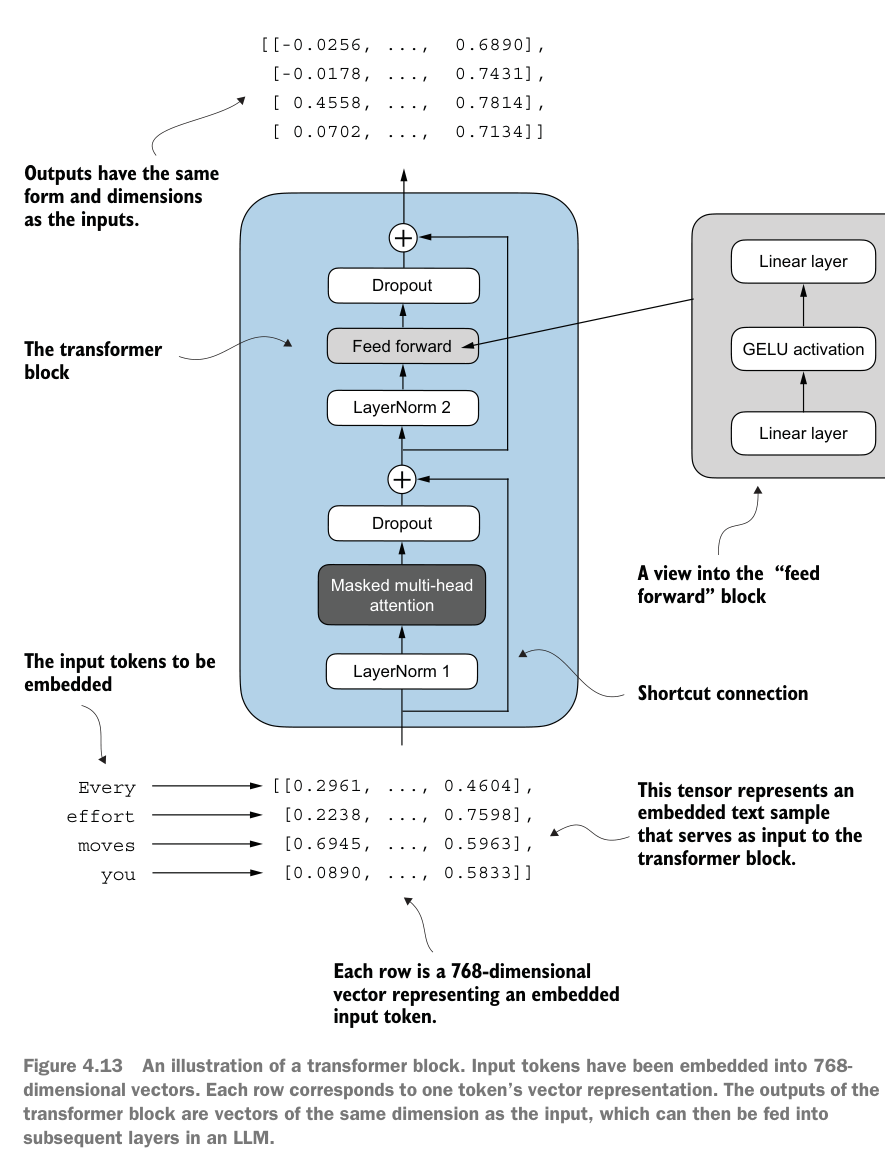

In [18]:
# --- Attention mechanisms
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # (batch_size, seq_length, embedding_dim)
        keys = self.W_key(x)             # (batch_size, seq_length, d_out)
        queries = self.W_query(x)        # (batch_size, seq_length, d_out)
        values = self.W_value(x)         # (batch_size, seq_length, d_out)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(1, 2)  # (batch_size, seq_length, seq_length)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)

        # Compute attention weights with softmax
        attn_weights = torch.softmax(attn_scores / self.d_out**0.5, dim=-1)

        # Apply dropout to the attention weights
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values  # (batch_size, seq_length, d_out)
        return context_vec


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce proj. dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)  # Linear lay layer to combine heads
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # (batch_size, seq_length, embedding_dim)

        keys = self.W_key(x)             # (batch_size, seq_length, d_out)
        queries = self.W_query(x)        # (batch_size, seq_length, d_out)
        values = self.W_value(x)         # (batch_size, seq_length, d_out)

        # Implicitly split matrix by adding num_heads dimension
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute dot product for each attention head
        attn_scores = queries @ keys.transpose(2, 3)

        # Mask truncated to number of tokens..?
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   # (b, num_tokens, num_heads, head_dim)

        # Combine heads, self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec


In [19]:
# --- Transformer block
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.atn = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.dropout_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.atn(x)
        x = self.dropout_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout_shortcut(x)

        return x + shortcut

In [20]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

# Transformer block maintains input dimension in its output.
# Good for stacking!
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


GPT Model

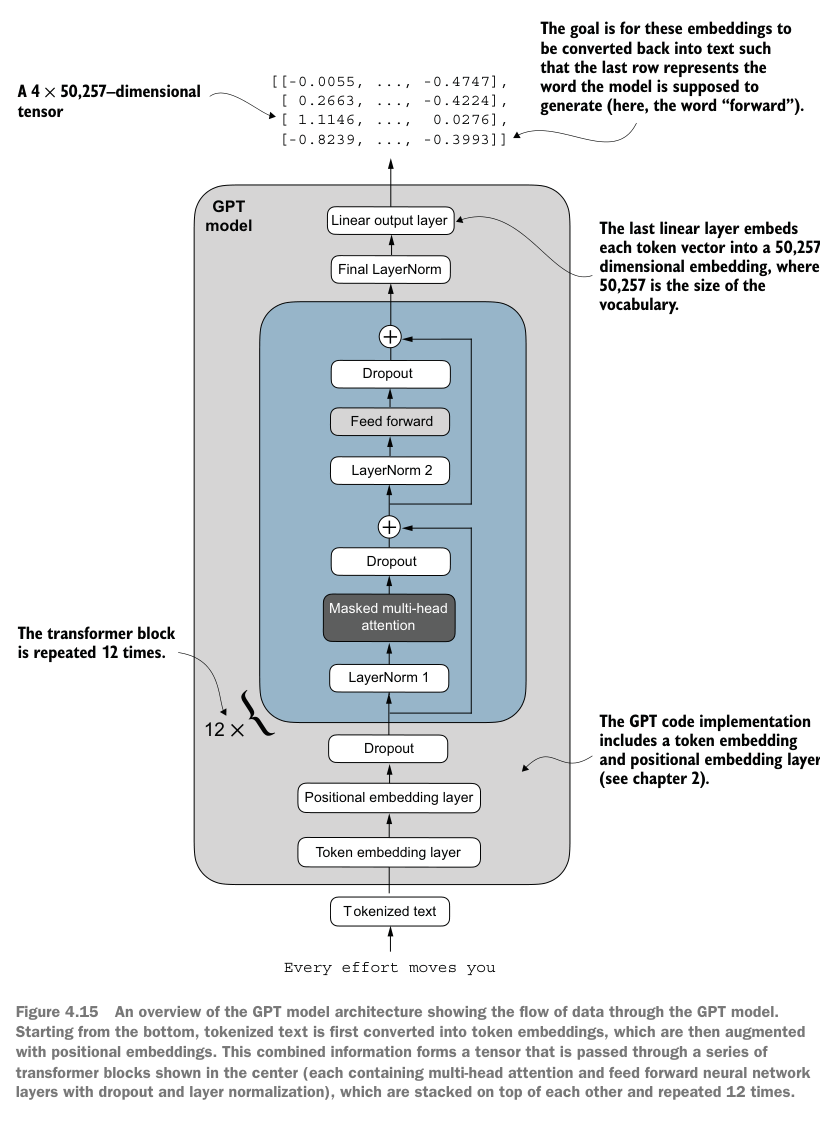

In [21]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [22]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print(f"Input batch:\n{batch}")
print(f"\nOutput shape: {out.shape}")       # Batch size, seq_len, vocab_size
print(f"Output:\n{output}")

Input batch:
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
Output:
tensor([[[-0.0053,  0.0976, -0.1119,  ...,  1.2888,  0.2626,  0.6683],
         [ 0.0028, -0.2366,  0.1721,  ...,  0.5953,  0.2498,  0.7447],
         [ 0.4675,  0.4470,  0.1792,  ...,  1.2521,  0.3048,  0.7748],
         [ 0.0664,  0.7225,  0.9206,  ...,  0.4790,  0.7428,  0.7014]],

        [[ 0.3623,  1.2142,  0.5221,  ...,  0.1853,  0.0114, -0.5029],
         [-0.0224,  0.7787,  0.2769,  ...,  0.1735,  0.5418,  0.1144],
         [ 0.7427,  0.4012,  0.3209,  ...,  0.3268,  0.7522, -0.1639],
         [ 0.5743,  0.6240,  0.4408,  ...,  1.1961,  1.2648,  0.2242]]],
       grad_fn=<AddBackward0>)


In [23]:
# Total params
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [24]:
# Token embedding and output layers very large due to number of rows
# for tokenizer vocab (50,257)
print(f"Token embedding layer shape: {model.tok_emb.weight.shape}")
print(f"Output layer shape: {model.out_head.weight.shape}")

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [25]:
total_param_gpt2 = (
    total_params - sum(p.numel() for p in model.out_head.parameters())
)

print(f"Number of trainable parameters considering weight tying: {total_param_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


Note that GPT-2 model specifies it has 124M but in this case it shows 163M. Reason is a concept called "weight-tying"

Weight tying:
- GPT-2 architecture reuses weights from token embedding layer in its output layer.
- Weight tying reduces overall memory footprint and computations
- In practice however, using separate token embedding and output layers result in better training and model performance

In [26]:
total_ff_params = 0
for trf_block in model.trf_blocks:
    total_ff_params += sum(p.numel() for p in trf_block.ff.parameters())
print(f"Total Feedforward params: {total_ff_params:,}")

total_mha_params = 0
for trf_block in model.trf_blocks:
    total_mha_params = sum(p.numel() for p in trf_block.atn.parameters())
print(f"Total multihead attention params: {total_mha_params:,}")

Total Feedforward params: 56,669,184
Total multihead attention params: 2,360,064


In [27]:
# -- Memory requirements
# Total size in bytes (asusming float32, 4 bytes per param)
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)        # Conversion to MB
print(f"Total size of the model: {total_size_mb:.2f} MB") 

Total size of the model: 621.83 MB


### Text Generation
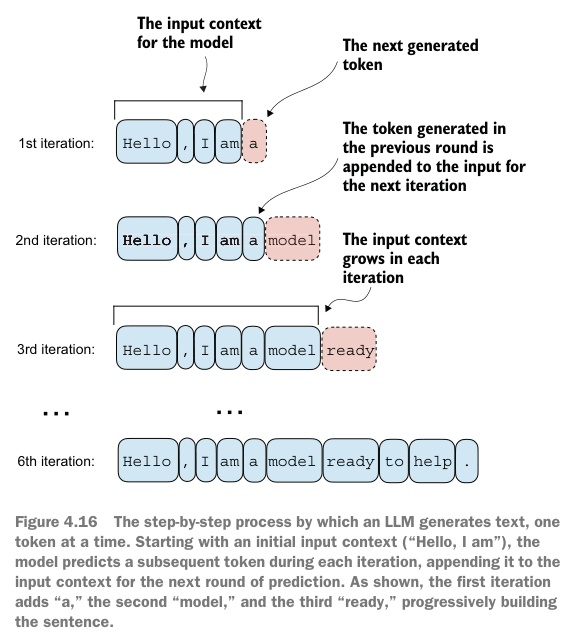

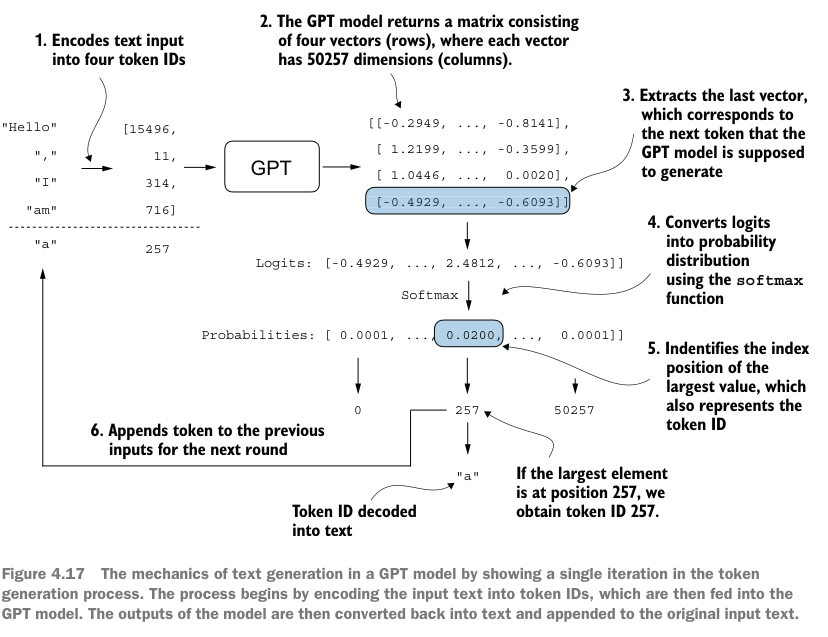

In [28]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is a (batch, n_tokens) array of indices in the current context

    for _ in range(max_new_tokens):
        # Crops current context if it exceeds the supported context size.
        # I.e if LLM supports only 5 tokens, and context size is 10,
        # then only last 5 tokens are used as context.
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step so that
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # probas has shape (batch, vocab_size)
        # NOTE: softmax is monotonic (i.e preserves order of inputs when transformed to outputs)
        # In practice could use torch.argmax
        probas = torch.softmax(logits, dim=-1)

        # idx_next has shape (batch, 1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # Appends sampled index to next running sequence, where idx shape (batch, n_tokens+1)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [29]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded: ", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)     # Add batch dimension
print("encoded_tensor.shape: ", encoded_tensor.shape)

encoded:  [15496, 11, 314, 716]
encoded_tensor.shape:  torch.Size([1, 4])


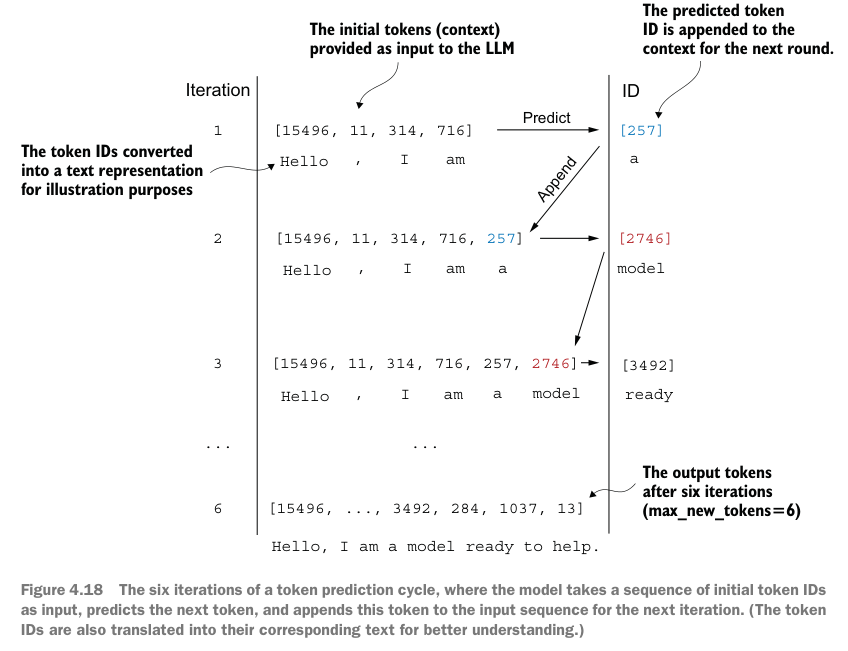

In [ ]:
# -- Model test run
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output: ", out)
print("Output length: ", len(out[0]))

print("---------------------------")
# Decoded text.
# NOTE: The model is untrained!
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(f"decoded_text: {decoded_text}")

Output:  tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length:  10
---------------------------
decoded_text: Hello, I am Featureiman Byeswickattribute argue
